Connect to Google Drive and Create MICOM Folder

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Creat main folder for project inputs and outputs
import os
ml_path = '/content/drive/MyDrive/Machine_Learning'
os.makedirs(ml_path, exist_ok=True)

In [1]:
from pathlib import Path

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import Feature Tables

In [4]:
import pandas as pd
from pathlib import Path

# Path to uploaded files (root of Colab)
ml_path = "/content"

rel_abd_features = pd.read_csv(Path(ml_path) / "relative_abundance_features.csv")
micom_features = pd.read_csv(Path(ml_path) / "micom_features.csv")

# verify load worked
print(rel_abd_features.shape)
print(micom_features.shape)

(93, 10)
(25, 8)


In [5]:
print(rel_abd_features)

     sample_id condition       PC1       PC2       PC3  Escherichia  \
0   SRR8061715        AD -2.420204  0.264267  2.695112     0.000000   
1   SRR8061716        AD -0.305117  0.802686  3.401735     0.509391   
2   SRR8061717        AD -0.655024 -0.822020  0.503503     0.294271   
3   SRR8061718        AD -0.517932  0.679205  3.005779     0.841240   
4   SRR8061719        AD -2.342568  1.186368  1.623629     0.000000   
..         ...       ...       ...       ...       ...          ...   
88  SRR8061803       MCI  2.245148 -0.389435  4.055000     0.178281   
89  SRR8061804       MCI  2.274504 -0.679650  1.003374     0.295258   
90  SRR8061805       MCI -0.002851  0.235047  1.655528     0.183633   
91  SRR8061806       MCI -2.346745 -0.576592 -1.549863     0.028533   
92  SRR8061807       MCI  1.069313 -1.520620 -0.468429     0.000000   

    Bacteroides   Blautia  Alistipes  Limosilactobacillus  
0      0.000000  0.061740   0.000000             0.563767  
1      0.030804  0.084899  

In [6]:
micom_copy = micom_features.copy()

In [7]:
# Replace NaN with 0
id_cols = ["sample_id", "condition"]
micom_feature_cols = [c for c in micom_features.columns if c not in id_cols]
micom_features[micom_feature_cols] = micom_features[micom_feature_cols].fillna(0)

In [8]:
print(micom_features)

     sample_id condition  EX_xyluglc_m  EX_rpn_96990_glc_m     EX_ac_m  \
0   SRR8061716        AD      0.000000            0.000000  690.466643   
1   SRR8061715        AD      0.000000            0.131094   -0.000016   
2   SRR8061718        AD      0.000000            0.000000  878.207937   
3   SRR8061722        AD      0.000000            0.000000  919.346421   
4   SRR8061719        AD     -0.037830            0.080319    0.037646   
5   SRR8061732        AD     -0.000000            0.000000  642.309347   
6   SRR8061734        AD     -0.000000            0.000000  867.447321   
7   SRR8061743        AD      0.000000            0.000000  852.189339   
8   SRR8061771        AD     -7.593526           12.586949    9.424648   
9   SRR8061772        AD     -1.085796            2.056029   11.857900   
10  SRR8061777        AD      0.000000            6.711693    4.216986   
11  SRR8061737       MCI      0.000000            0.000042    0.456690   
12  SRR8061735       MCI      0.000000

In [9]:
# Rename MICOM condition column
micom_features = micom_features.rename(columns={"condition": "condition_micom"})

In [10]:
# Merge feature tables
ml_features = rel_abd_features.merge(micom_features, on="sample_id", how="inner")

In [11]:
# Remove extra condition columns
ml_features = ml_features.drop(columns=["condition_micom"])

In [12]:
print("Machine Learning Features: ", ml_features.shape)
print(ml_features.head())

Machine Learning Features:  (25, 16)
    sample_id condition       PC1       PC2       PC3  Escherichia  \
0  SRR8061715        AD -2.420204  0.264267  2.695112     0.000000   
1  SRR8061716        AD -0.305117  0.802686  3.401735     0.509391   
2  SRR8061718        AD -0.517932  0.679205  3.005779     0.841240   
3  SRR8061719        AD -2.342568  1.186368  1.623629     0.000000   
4  SRR8061722        AD -0.213649  0.991315  3.570985     0.905615   

   Bacteroides   Blautia  Alistipes  Limosilactobacillus  EX_xyluglc_m  \
0     0.000000  0.061740        0.0             0.563767       0.00000   
1     0.030804  0.084899        0.0             0.000000       0.00000   
2     0.000000  0.011743        0.0             0.020667       0.00000   
3     0.000000  0.105855        0.0             0.000000      -0.03783   
4     0.000000  0.000000        0.0             0.000000       0.00000   

   EX_rpn_96990_glc_m     EX_ac_m    EX_co2_m  EX_7ocholate_m     growth  
0            0.131094 

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

Train Models with Only Relative Abundance Features

In [14]:
# X = features
# y = labels
X_ra = rel_abd_features.drop(columns=["sample_id", "condition"])
y_ra = rel_abd_features["condition"]

In [15]:
# Set train/test split
X_train_ra, X_test_ra, y_train_ra, y_test_ra = train_test_split(
    X_ra,
    y_ra,
    test_size = 0.3,
    random_state = 5,
    stratify = y_ra)    # same proportion of each condition

Model A: Support Vector Machine

In [16]:
# Create SVM pipeline
# Use RBF kernel b/c likely a non-linear relationship
svm_ra = Pipeline([
    ("scaler", StandardScaler()),    # Scale the data
    ("svm", SVC(kernel = "rbf", probability = True, random_state =5 ))])

In [17]:
# Run k-fold cross-validation
# Training data split into k groups, trained on k-1 groups, tested on remaining group
# cv = 5
svm_ra_cv = cross_val_score(svm_ra, X_train_ra, y_train_ra, cv = 5)
print("\n[RA] SVM 5-fold CV accuracy:", svm_ra_cv.mean())


[RA] SVM 5-fold CV accuracy: 0.5846153846153845


In [18]:
svm_ra.fit(X_train_ra, y_train_ra)
y_pred_svm_ra = svm_ra.predict(X_test_ra)

In [19]:
print("\n[RA] SVM classification report:")
print(classification_report(y_test_ra, y_pred_svm_ra))


[RA] SVM classification report:
              precision    recall  f1-score   support

          AD       0.44      0.40      0.42        10
     Healthy       0.25      0.25      0.25         8
         MCI       0.36      0.40      0.38        10

    accuracy                           0.36        28
   macro avg       0.35      0.35      0.35        28
weighted avg       0.36      0.36      0.36        28



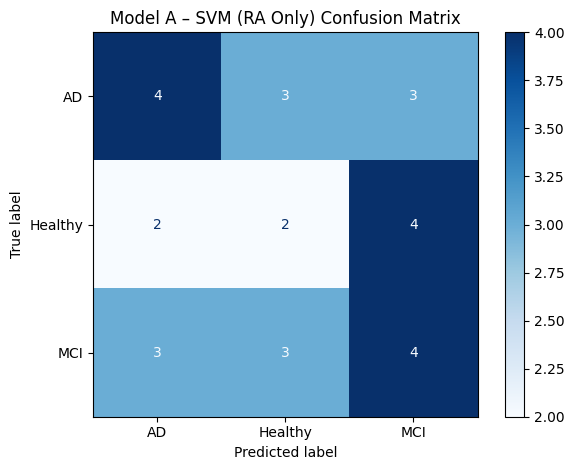

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test_ra, y_pred_svm_ra, labels=svm_ra.classes_)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_ra.classes_)
disp.plot(cmap="Blues", values_format='d')
plt.title("Model A – SVM (RA Only) Confusion Matrix")
plt.tight_layout()
plt.savefig("modelA_confusion_matrix.png", dpi=200)
plt.show()

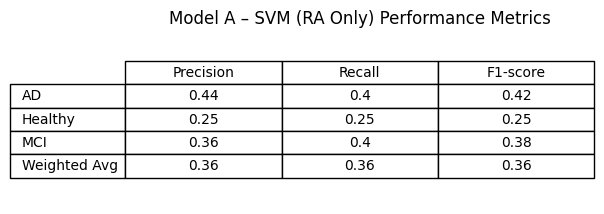

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Get classification report as dataframe
report = classification_report(y_test_ra, y_pred_svm_ra, output_dict=True)
df = pd.DataFrame(report).transpose()

# Keep only rows we need
df = df.loc[["AD", "Healthy", "MCI", "weighted avg"]]
df = df[["precision", "recall", "f1-score"]].round(2)

# Rename for display clarity
df.index = ["AD", "Healthy", "MCI", "Weighted Avg"]
df.columns = ["Precision", "Recall", "F1-score"]

# Plot as table
fig, ax = plt.subplots(figsize=(5.5, 2.2))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.4)

plt.title("Model A – SVM (RA Only) Performance Metrics", fontsize=12, pad=8)

plt.savefig("modelA_metrics_table.png", dpi=200, bbox_inches="tight")
plt.show()

Model B: Random Forest

In [22]:
rf_ra = RandomForestClassifier(
    n_estimators = 500,  # number of trees
    random_state = 10,
    n_jobs = -1,
    class_weight = "balanced")

In [23]:
rf_ra_cv_scores = cross_val_score(rf_ra, X_train_ra, y_train_ra, cv = 5)
print("\n[RA] Random Forest 5-fold CV accuracy:", rf_ra_cv_scores.mean())


[RA] Random Forest 5-fold CV accuracy: 0.49230769230769234


In [24]:
rf_ra.fit(X_train_ra, y_train_ra)
y_pred_rf_ra = rf_ra.predict(X_test_ra)

In [25]:
print("\n[RA] Random Forest classification report:")
print(classification_report(y_test_ra, y_pred_rf_ra))


[RA] Random Forest classification report:
              precision    recall  f1-score   support

          AD       0.33      0.20      0.25        10
     Healthy       0.18      0.25      0.21         8
         MCI       0.45      0.50      0.48        10

    accuracy                           0.32        28
   macro avg       0.32      0.32      0.31        28
weighted avg       0.33      0.32      0.32        28



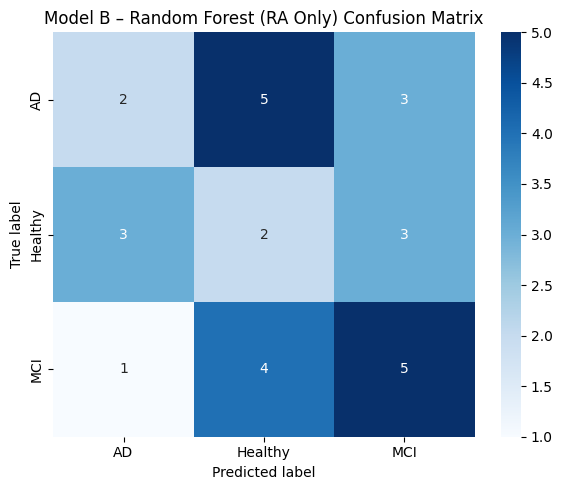

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["AD", "Healthy", "MCI"]

cm_rf_ra = confusion_matrix(y_test_ra, y_pred_rf_ra)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf_ra,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Model B – Random Forest (RA Only) Confusion Matrix")
plt.tight_layout()
plt.show()

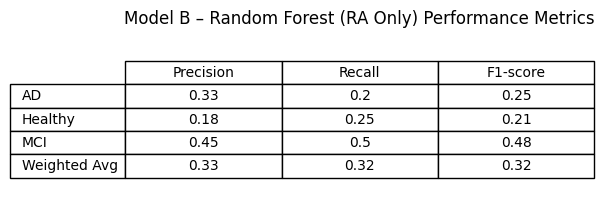

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Get classification report as dataframe
report = classification_report(y_test_ra, y_pred_rf_ra, output_dict=True)
df = pd.DataFrame(report).transpose()

# Keep only rows we need
df = df.loc[["AD", "Healthy", "MCI", "weighted avg"]]
df = df[["precision", "recall", "f1-score"]].round(2)

# Rename for display clarity
df.index = ["AD", "Healthy", "MCI", "Weighted Avg"]
df.columns = ["Precision", "Recall", "F1-score"]

# Plot as table (MATCHES TABLE 1 STYLE)
fig, ax = plt.subplots(figsize=(5.5, 2.2))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.4)

plt.title("Model B – Random Forest (RA Only) Performance Metrics", fontsize=12, pad=8)

plt.savefig("modelB_metrics_table.png", dpi=200, bbox_inches="tight")
plt.show()


Train Models with Relative Abundance and MICOM Features

*   List item
*   List item



In [29]:
ra_cols_for_both = [
    "PC1", "PC2", "PC3",
    "Escherichia", "Bacteroides", "Blautia",
    "Alistipes", "Limosilactobacillus"]

micom_cols_for_both = [
    "EX_xyluglc_m",
    "EX_rpn_96990_glc_m",
    "EX_ac_m",
    "EX_co2_m",
    "EX_7ocholate_m",
    "growth"]

In [30]:
selected_cols_both = ["sample_id", "condition"] + ra_cols_for_both + micom_cols_for_both

In [31]:
ml_features_both = ml_features[selected_cols_both].copy()

In [32]:
print(ml_features_both.head())

    sample_id condition       PC1       PC2       PC3  Escherichia  \
0  SRR8061715        AD -2.420204  0.264267  2.695112     0.000000   
1  SRR8061716        AD -0.305117  0.802686  3.401735     0.509391   
2  SRR8061718        AD -0.517932  0.679205  3.005779     0.841240   
3  SRR8061719        AD -2.342568  1.186368  1.623629     0.000000   
4  SRR8061722        AD -0.213649  0.991315  3.570985     0.905615   

   Bacteroides   Blautia  Alistipes  Limosilactobacillus  EX_xyluglc_m  \
0     0.000000  0.061740        0.0             0.563767       0.00000   
1     0.030804  0.084899        0.0             0.000000       0.00000   
2     0.000000  0.011743        0.0             0.020667       0.00000   
3     0.000000  0.105855        0.0             0.000000      -0.03783   
4     0.000000  0.000000        0.0             0.000000       0.00000   

   EX_rpn_96990_glc_m     EX_ac_m    EX_co2_m  EX_7ocholate_m     growth  
0            0.131094   -0.000016   -1.470971        0.0000

In [33]:
X_both = ml_features_both.drop(columns=["sample_id", "condition"])
y_both = ml_features_both["condition"]

In [34]:
X_both_train, X_both_test, y_both_train, y_both_test = train_test_split(
    X_both,
    y_both,
    test_size = 0.3,
    random_state = 15,
    stratify = y_both)

Model C: Support Vector Machine

In [35]:
svm_both = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel = "rbf", probability = True, random_state = 15))])

In [36]:
svm_both.fit(X_both_train, y_both_train)
y_both_pred_svm = svm_both.predict(X_both_test)

In [37]:
print("\n[RA+MICOM] SVM Classification Report:")
print(classification_report(y_both_test, y_both_pred_svm))


[RA+MICOM] SVM Classification Report:
              precision    recall  f1-score   support

          AD       0.60      0.75      0.67         4
     Healthy       0.00      0.00      0.00         2
         MCI       0.67      1.00      0.80         2

    accuracy                           0.62         8
   macro avg       0.42      0.58      0.49         8
weighted avg       0.47      0.62      0.53         8



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


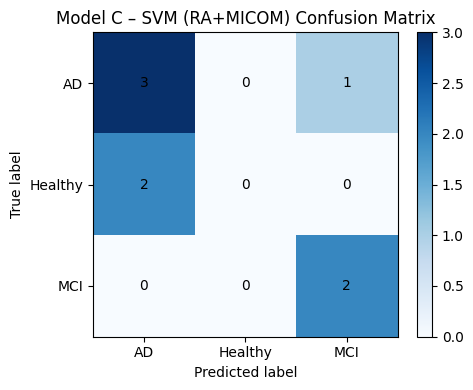

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Confusion matrix
cm_c = confusion_matrix(y_both_test, y_both_pred_svm, labels=["AD", "Healthy", "MCI"])
classes = ["AD", "Healthy", "MCI"]

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(cm_c, cmap="Blues")

# Ticks and labels
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Model C – SVM (RA+MICOM) Confusion Matrix")

# Add text in cells
for i in range(cm_c.shape[0]):
    for j in range(cm_c.shape[1]):
        ax.text(j, i, cm_c[i, j],
                ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("modelC_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


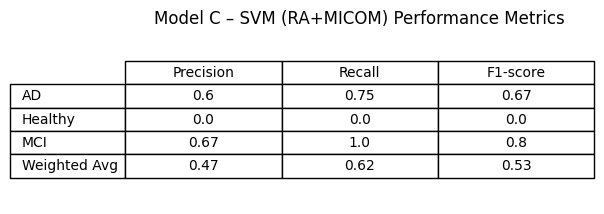

In [39]:
import pandas as pd
from sklearn.metrics import classification_report

# Get classification report as dataframe
report_c = classification_report(y_both_test, y_both_pred_svm, output_dict=True)
df_c = pd.DataFrame(report_c).transpose()

# Keep rows of interest
df_c = df_c.loc[["AD", "Healthy", "MCI", "weighted avg"]]
df_c = df_c[["precision", "recall", "f1-score"]].round(2)

# Rename for display clarity
df_c.index = ["AD", "Healthy", "MCI", "Weighted Avg"]
df_c.columns = ["Precision", "Recall", "F1-score"]

# Plot as table
fig, ax = plt.subplots(figsize=(5.5, 2.2))
ax.axis("off")

table = ax.table(
    cellText=df_c.values,
    colLabels=df_c.columns,
    rowLabels=df_c.index,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.4)

plt.title("Model C – SVM (RA+MICOM) Performance Metrics", fontsize=12, pad=8)

plt.savefig("modelC_metrics_table.png", dpi=200, bbox_inches="tight")
plt.show()

Model D: Random Forest

In [40]:
rf_both = RandomForestClassifier(
    n_estimators = 500,
    class_weight = "balanced",
    random_state = 15)

In [41]:
rf_both.fit(X_both_train, y_both_train)
y_both_pred_rf = rf_both.predict(X_both_test)

In [42]:
print("\n[RA+MICOM] Random Forest Classification Report:")
print(classification_report(y_both_test, y_both_pred_rf))


[RA+MICOM] Random Forest Classification Report:
              precision    recall  f1-score   support

          AD       0.75      0.75      0.75         4
     Healthy       0.50      0.50      0.50         2
         MCI       0.50      0.50      0.50         2

    accuracy                           0.62         8
   macro avg       0.58      0.58      0.58         8
weighted avg       0.62      0.62      0.62         8



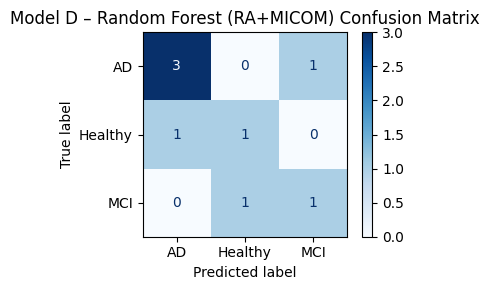

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_both_test, y_both_pred_rf, labels=["AD", "Healthy", "MCI"])

# Plot
fig, ax = plt.subplots(figsize=(4, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["AD", "Healthy", "MCI"])
disp.plot(ax=ax, cmap="Blues", colorbar=True)

plt.title("Model D – Random Forest (RA+MICOM) Confusion Matrix", fontsize=12)
plt.tight_layout()
plt.savefig("modelD_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


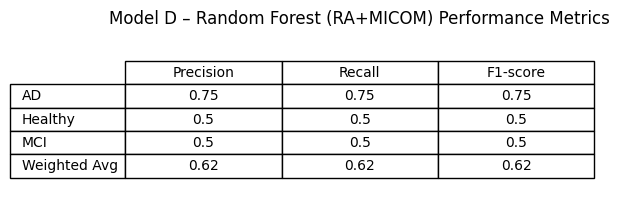

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Convert classification report to dataframe
report = classification_report(y_both_test, y_both_pred_rf, output_dict=True)
df = pd.DataFrame(report).transpose()

# Keep required rows
df = df.loc[["AD", "Healthy", "MCI", "weighted avg"]]
df = df[["precision", "recall", "f1-score"]].round(2)

# Rename for clear display
df.index = ["AD", "Healthy", "MCI", "Weighted Avg"]
df.columns = ["Precision", "Recall", "F1-score"]

# Plot as table
fig, ax = plt.subplots(figsize=(5.5, 2.2))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.4)

plt.title("Model D – Random Forest (RA+MICOM) Performance Metrics", fontsize=12, pad=8)

plt.savefig("modelD_metrics_table.png", dpi=200, bbox_inches="tight")
plt.show()


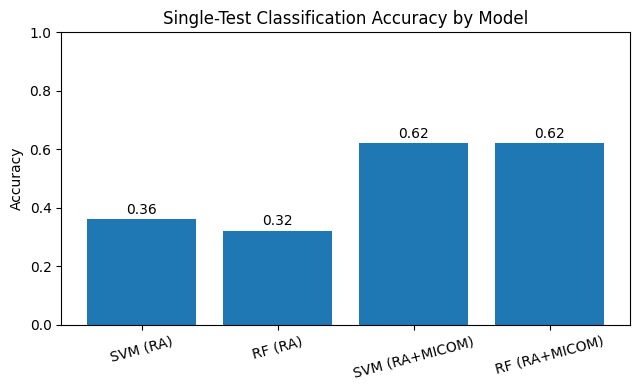

In [45]:
import matplotlib.pyplot as plt

# ---- Final test accuracies ----
model_names = [
    "SVM (RA)",
    "RF (RA)",
    "SVM (RA+MICOM)",
    "RF (RA+MICOM)"
]

accuracies = [
    0.36,   # Model A
    0.32,   # Model B
    0.62,   # Model C
    0.62    # Model D
]

# ---- Plot ----
plt.figure(figsize=(6.5, 4))

bars = plt.bar(model_names, accuracies)

# Annotate bars with values
for bar, val in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.02,
        f"{val:.2f}",
        ha="center",
        fontsize=10
    )

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Single-Test Classification Accuracy by Model", fontsize=12)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("Figure5_Model_Accuracy_Comparison.png", dpi=200)
plt.show()


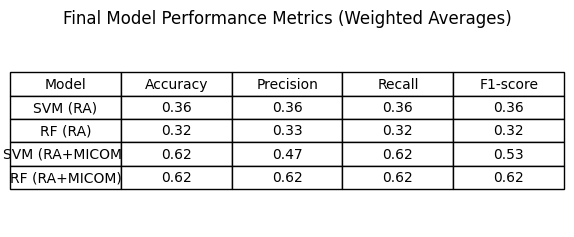

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Weighted Metrics For Each Model ----
data = {
    "Model": [
        "SVM (RA)",
        "RF (RA)",
        "SVM (RA+MICOM)",
        "RF (RA+MICOM)"
    ],
    "Accuracy": [0.36, 0.32, 0.62, 0.62],
    "Precision": [0.36, 0.33, 0.47, 0.62],
    "Recall": [0.36, 0.32, 0.62, 0.62],
    "F1-score": [0.36, 0.32, 0.53, 0.62]
}

df = pd.DataFrame(data).round(2)

# ---- Plot as formatted table ----
fig, ax = plt.subplots(figsize=(6.5, 2.5))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.4)

plt.title(
    "Final Model Performance Metrics (Weighted Averages)",
    fontsize=12,
    pad=8
)

plt.savefig("Table5_Final_Weighted_Metrics.png", dpi=200, bbox_inches="tight")
plt.show()

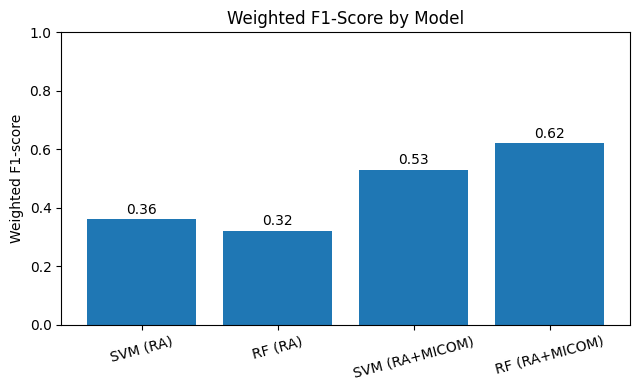

In [47]:
# ---- Weighted F1-score comparison ----

model_names = [
    "SVM (RA)",
    "RF (RA)",
    "SVM (RA+MICOM)",
    "RF (RA+MICOM)"
]

f1_scores = [0.36, 0.32, 0.53, 0.62]

plt.figure(figsize=(6.5, 4))

bars = plt.bar(model_names, f1_scores)

for bar, val in zip(bars, f1_scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.02,
        f"{val:.2f}",
        ha="center",
        fontsize=10
    )

plt.ylim(0, 1)
plt.ylabel("Weighted F1-score")
plt.title("Weighted F1-Score by Model", fontsize=12)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("Figure6_Weighted_F1_Comparison.png", dpi=200)
plt.show()